**1) Import Libraries**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**2) Load + Reduce CIFAR-10**

In [ ]:
import requests
import tarfile
import pickle
import os
import numpy as np

url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"
file_path = "/content/cifar-10-python.tar.gz"

print("Downloading CIFAR-10 from mirror...")

response = requests.get(url, stream=True)
response.raise_for_status()

with open(file_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print("Download complete!")

with tarfile.open(file_path, "r:gz") as tar:
    tar.extractall("/content")

print("Dataset extracted!")

Download complete!


/tmp/ipykernel_1913/3123288401.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


Dataset extracted!


**3) Preprocessing Setup**

In [ ]:
def load_batch(file):
    with open(file, 'rb') as f:
        data = pickle.load(f, encoding='bytes')
    return data[b'data'], data[b'labels']

x_train = []
y_train = []

for i in range(1, 6):
    data, labels = load_batch(
        f"/content/cifar-10-batches-py/data_batch_{i}"
    )
    x_train.append(data)
    y_train.extend(labels)

x_train = np.concatenate(x_train)
y_train = np.array(y_train)

x_test, y_test = load_batch(
    "/content/cifar-10-batches-py/test_batch"
)

# Convert to image format
x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Use smaller subset for the lab
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (10000, 32, 32, 3)
Testing : (2000, 32, 32, 3)


**4) Classes + Sample Images + Parameters**

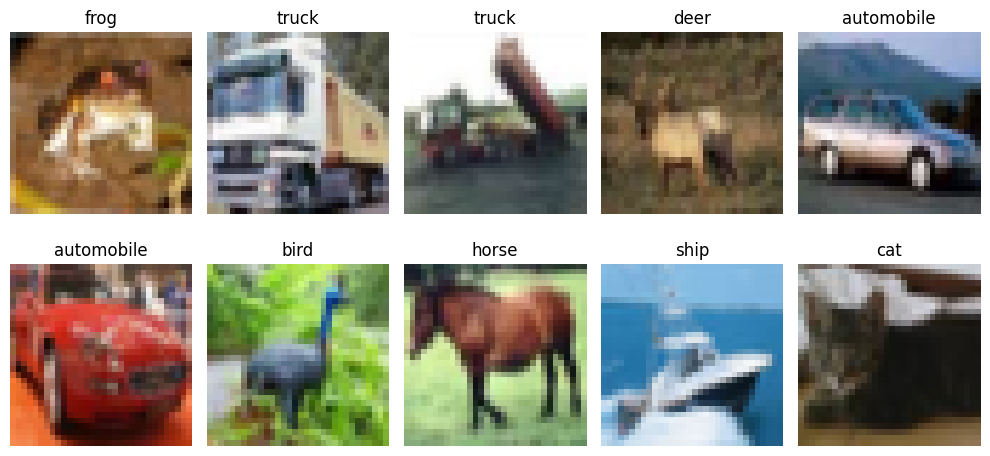

In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 2

**5) Preprocessing / Data Pipeline**

In [ ]:
# Validation split
x_val = x_train[:1000]
y_val = y_train[:1000]

x_train_new = x_train[1000:]
y_train_new = y_train[1000:]


def make_dataset(x, y, preprocess):
    dataset = tf.data.Dataset.from_tensor_slices((x, y))

    def process(image, label):
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess(image)
        return image, label

    dataset = dataset.map(
        process,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_vgg = make_dataset(
    x_train_new, y_train_new, vgg_preprocess
)

val_vgg = make_dataset(
    x_val, y_val, vgg_preprocess
)

test_vgg = make_dataset(
    x_test, y_test, vgg_preprocess
)

print("Preprocessing completed!")

Preprocessing completed!


**6) VGG16 Model + Training + Evaluation**

In [ ]:
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
# Freeze pretrained layers
vgg_base.trainable = False
vgg_model = models.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg_model.summary()
start = time.time()
vgg_history = vgg_model.fit(
    train_vgg,
    epochs=EPOCHS,
    validation_data=val_vgg
)
vgg_time = time.time() - start
vgg_loss, vgg_acc = vgg_model.evaluate(
    test_vgg, verbose=0
)
print("\nVGG16 Test Accuracy:",
      round(vgg_acc * 100, 2), "%")
print("VGG16 Test Loss:",
      round(vgg_loss, 4))
print("VGG16 Training Time:",
      round(vgg_time, 2), "seconds")
print("\nVGG16 Final Layer:")
print(vgg_model.layers[-1])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/2
282/282 ━━━━━━━━━━━━━━━━━━━━ 73s 201ms/step - accuracy: 0.5400 - loss: 1.4451 - val_accuracy: 0.7500 - val_loss: 0.7142
Epoch 2/2
282/282 ━━━━━━━━━━━━━━━━━━━━ 60s 212ms/step - accuracy: 0.7182 - loss: 0.8356 - val_accuracy: 0.8000 - val_loss: 0.5957

VGG16 Test Accuracy: 80.15 %
VGG16 Test Loss: 0.6086
VGG16 Training Time: 154.85 seconds

VGG16 Final Layer:
<Dense name=dense_1, built=True>


**7) VGG16 Accuracy Graph**

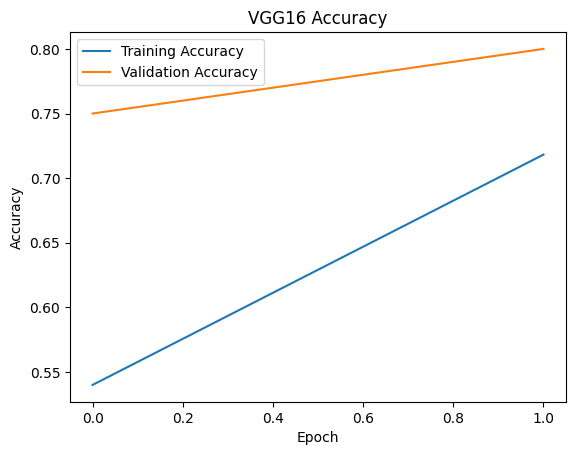

In [ ]:
plt.plot(
    vgg_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    vgg_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**8) Prepare ResNet50 Dataset**

In [ ]:
train_resnet = make_dataset(
    x_train_new, y_train_new, resnet_preprocess
)

val_resnet = make_dataset(
    x_val, y_val, resnet_preprocess
)

test_resnet = make_dataset(
    x_test, y_test, resnet_preprocess
)

print("ResNet50 dataset ready!")

ResNet50 dataset ready!


**9) ResNet50 Model + Training + Evaluation**

In [ ]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
resnet_base.trainable = False
resnet_model = models.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
resnet_model.summary()
start = time.time()
resnet_history = resnet_model.fit(
    train_resnet,
    epochs=EPOCHS,
    validation_data=val_resnet
)
resnet_time = time.time() - start
resnet_loss, resnet_acc = resnet_model.evaluate(
    test_resnet, verbose=0
)
print("\nResNet50 Test Accuracy:",
      round(resnet_acc * 100, 2), "%")
print("ResNet50 Test Loss:",
      round(resnet_loss, 4))
print("ResNet50 Training Time:",
      round(resnet_time, 2), "seconds")
print("\nResNet50 Final Layer:")
print(resnet_model.layers[-1])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/2
282/282 ━━━━━━━━━━━━━━━━━━━━ 56s 146ms/step - accuracy: 0.7163 - loss: 0.8387 - val_accuracy: 0.8600 - val_loss: 0.3858
Epoch 2/2
282/282 ━━━━━━━━━━━━━━━━━━━━ 28s 100ms/step - accuracy: 0.8382 - loss: 0.4875 - val_accuracy: 0.8820 - val_loss: 0.3494

ResNet50 Test Accuracy: 88.15 %
ResNet50 Test Loss: 0.3417
ResNet50 Training Time: 84.09 seconds

ResNet50 Final Layer:
<Dense name=dense_3, built=True>


**10) ResNet50 Accuracy Graph**

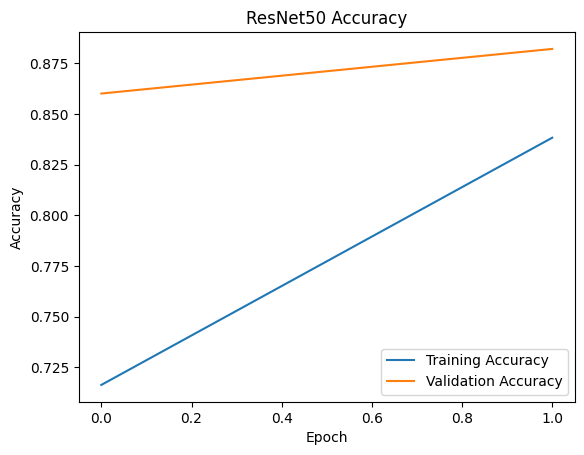

In [ ]:
plt.plot(
    resnet_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    resnet_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**11) VGG16 vs ResNet50 Comparison**

========== PERFORMANCE COMPARISON ==========
VGG16 Test Accuracy    : 80.15%
ResNet50 Test Accuracy : 88.15%

VGG16 Training Time    : 154.85 sec
ResNet50 Training Time : 84.09 sec


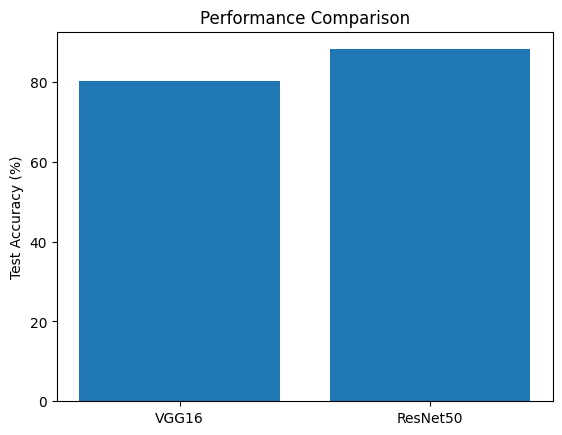

In [ ]:
print("========== PERFORMANCE COMPARISON ==========")
print(f"VGG16 Test Accuracy    : {vgg_acc * 100:.2f}%")
print(f"ResNet50 Test Accuracy : {resnet_acc * 100:.2f}%")
print(f"\nVGG16 Training Time    : {vgg_time:.2f} sec")
print(f"ResNet50 Training Time : {resnet_time:.2f} sec")
plt.bar(
    ['VGG16', 'ResNet50'],
    [vgg_acc * 100, resnet_acc * 100]
)

plt.ylabel('Test Accuracy (%)')
plt.title('Performance Comparison')
plt.show()

**12) Select Best Model + Display Final Layer**

In [ ]:
if vgg_acc >= resnet_acc:
    best_model = vgg_model
    best_name = "VGG16"
    best_acc = vgg_acc
    best_test = test_vgg
else:
    best_model = resnet_model
    best_name = "ResNet50"
    best_acc = resnet_acc
    best_test = test_resnet

print("========== SELECTED MODEL ==========")
print("Model:", best_name)
print("Test Accuracy:", round(best_acc * 100, 2), "%")

print("\nFinal Layer:")
print(best_model.layers[-1])

print("\nFinal Layer Configuration:")
print(best_model.layers[-1].get_config())

print("\nModel Output Shape:")
print(best_model.output_shape)

========== SELECTED MODEL ==========
Model: ResNet50
Test Accuracy: 88.15 %

Final Layer:
<Dense name=dense_3, built=True>

Final Layer Configuration:
{'name': 'dense_3', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 10, 'activation': 'softmax', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'quantization_config': None}

Model Output Shape:
(None, 10)


**13) Classification Report**

In [ ]:
predictions = best_model.predict(best_test)

predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step
              precision    recall  f1-score   support

    airplane       0.87      0.89      0.88       196
  automobile       0.90      0.92      0.91       198
        bird       0.91      0.78      0.84       195
         cat       0.81      0.82      0.82       199
        deer       0.82      0.88      0.85       198
         dog       0.93      0.76      0.84       185
        frog       0.88      0.95      0.92       216
       horse       0.87      0.93      0.90       193
        ship       0.97      0.94      0.95       217
       truck       0.87      0.93      0.90       203

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



**14) Confusion Matrix**

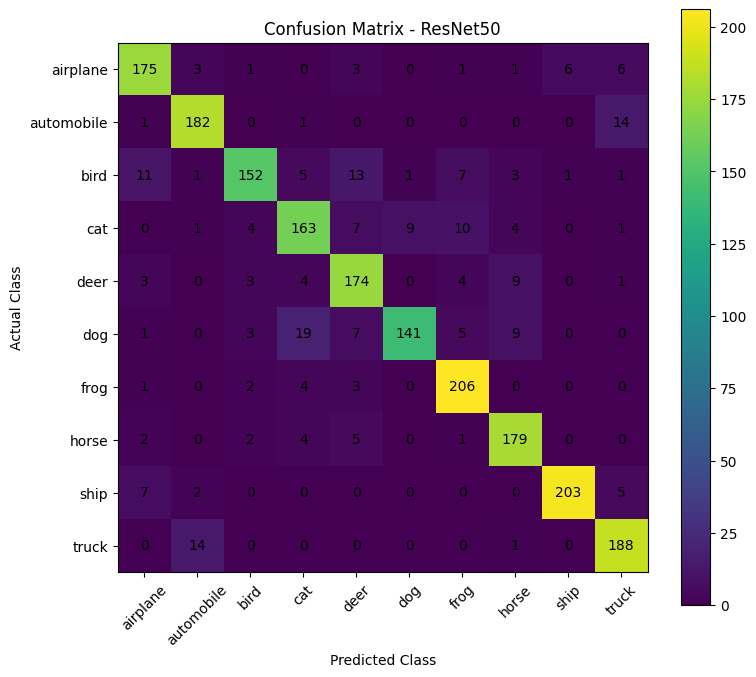

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title("Confusion Matrix - " + best_name)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

# Display values inside the matrix
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.tight_layout()
plt.show()